1. What neural network architecture did you use?

 - A fully connected feed-forward network

2. How many epochs did you train your model?

- `12`

3. What activation functions did you use?

- `ReLU`

4. What accuracy did your model achieve?

- `0.84`

In [20]:
import torch
import torch.nn as nn
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [21]:
import nltk
nltk.download('stopwords')
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

## Loading fakenews data from kaggle

In [22]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("algord/fake-news")


Using Colab cache for faster access to the 'fake-news' dataset.


In [23]:

df=pd.read_csv(f'{path}/FakeNewsNet.csv')
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [24]:
df=df[['title','source_domain','real']]
df.head()
df['real'].value_counts()

,count
real,
1,17441
0,5755


## Cleaning Nan and handling duplicates

In [25]:
print(f'Duplicate Titles: {df.duplicated(['title']).sum()} \n Na values {df.isna().sum()}')

df.dropna(inplace=True)

df.drop_duplicates( inplace=True,subset=['title'],keep='first')

# print(df.shape)
df.info()

Duplicate Titles: 1472 
 Na values title              0
source_domain    330
real               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 21398 entries, 0 to 23195
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          21398 non-null  object
 1   source_domain  21398 non-null  object
 2   real           21398 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 668.7+ KB


## Processing the text

In [26]:
import re
stemmer=PorterStemmer()
def sanitize_domain(domain):
    if pd.isna(domain):
        return ''
    domain = re.sub(r'^https?://', '', domain)
    domain = re.sub(r'^www\.', '', domain)
    domain = re.sub(r'[.-]', ' ', domain)
    return domain
def process_txt(content):
    content=re.sub(r'[^a-zA-Z]', ' ', str(content)).lower().split()
    return ' '.join([stemmer.stem(word) for word in content if word  not in stopwords.words("english")])
# process_txt(df['title'][0]) 
vectorizor=TfidfVectorizer()
df['title']=df['title'].apply(process_txt)
df['source_domain']=df['source_domain'].apply(sanitize_domain)
df['combined_txt']=df['source_domain']+' '+df['title']
df.head()

,title,source_domain,real,combined_txt
0,kandi burruss explod rape accus real housew at...,toofab com,1,toofab com kandi burruss explod rape accus rea...
1,peopl choic award best red carpet look,today com,1,today com peopl choic award best red carpet look
2,sophia bush send sweet birthday messag one tre...,etonline com,1,etonline com sophia bush send sweet birthday m...
3,colombian singer maluma spark rumour inappropr...,dailymail co uk,1,dailymail co uk colombian singer maluma spark ...
4,gossip girl year later upper east sider shock ...,zerchoo com,1,zerchoo com gossip girl year later upper east ...


In [27]:
from sklearn.model_selection import train_test_split
X=df['combined_txt']
Y = df["real"].astype(int).to_numpy()
x_train_raw, x_test_raw,y_train,y_test = train_test_split(X,Y, stratify=Y, random_state=23,test_size=0.2)
x_train=vectorizor.fit_transform(x_train_raw)
x_test=vectorizor.transform(x_test_raw)
np.unique_counts(y_test)

UniqueCountsResult(values=array([0, 1]), counts=array([ 999, 3281]))

In [28]:
x_train_t = torch.tensor(x_train.toarray(), dtype=torch.float32)
x_test_t = torch.tensor(x_test.toarray(), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## Neural Network

In [29]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(x_train_t.shape[1],256), #This selects size of a single row
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self,x):
        return self.model(x)

In [30]:
import torch.optim as optim
model =NeuralNetwork()
optimizer=optim.Adam(model.parameters(),lr=0.001)
pos_weight = torch.tensor([0.3]) # Fake/Real
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


##  Training


In [31]:
epochs=12
for epoch in range(epochs):
    out=model(x_train_t)
    loss=criterion(out,y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'epoch {epoch}: Loss: {loss.item()}')


epoch 0: Loss: 0.3218953311443329
epoch 1: Loss: 0.3216286301612854
epoch 2: Loss: 0.32131844758987427
epoch 3: Loss: 0.3209213316440582
epoch 4: Loss: 0.32043322920799255
epoch 5: Loss: 0.31978291273117065
epoch 6: Loss: 0.3189595639705658
epoch 7: Loss: 0.3179711103439331
epoch 8: Loss: 0.3167661726474762
epoch 9: Loss: 0.3153335750102997
epoch 10: Loss: 0.31367403268814087
epoch 11: Loss: 0.31174150109291077


## Tests

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()
with torch.no_grad():
    logits = model(x_test_t)                      # raw outputs
    test_loss = criterion(logits, y_test_t).item()

    probs = torch.sigmoid(logits)                # convert logits -> probabilities
    preds = (probs >= 0.5).int()                 # class predictions (0/1)

y_true = y_test_t.cpu().numpy().ravel()
y_pred = preds.cpu().numpy().ravel()
y_prob = probs.cpu().numpy().ravel()

print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(np.unique_counts(y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Test Loss: 0.3129
Accuracy : 0.8444
Precision: 0.8822
Recall   : 0.9198
F1 Score : 0.9006
UniqueCountsResult(values=array([0, 1], dtype=int32), counts=array([ 859, 3421]))
Confusion Matrix:
 [[ 596  403]
 [ 263 3018]]


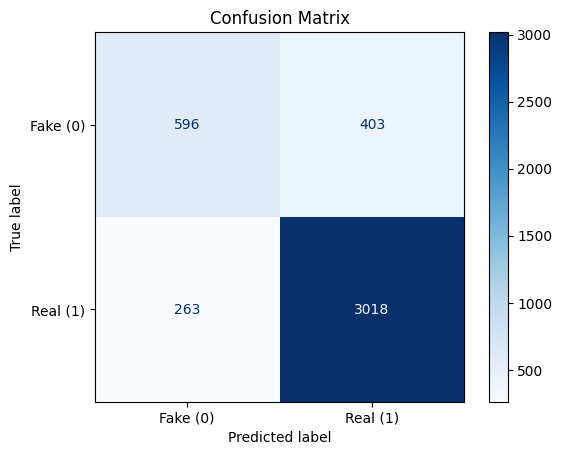

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake (0)", "Real (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def predict_news_label(headline: str, source_domain: str = ""):
    """
    Predict whether a news item is Fake (0) or Real (1) using the trained model.
    """
    model.eval()

    clean_title = process_txt(headline)
    clean_domain = sanitize_domain(source_domain)
    combined_text = f"{clean_domain} {clean_title}".strip()

    x_vec = vectorizor.transform([combined_text])  # same TF-IDF pipeline
    x_t = torch.tensor(x_vec.toarray(), dtype=torch.float32)

    with torch.no_grad():
        logit = model(x_t)
        prob_real = torch.sigmoid(logit).item()  # P(class=1 => Real)

    label = "Real" if prob_real >= 0.5 else "Fake"
    confidence = prob_real if label == "Real" else (1 - prob_real)

    return {
        "label": label,
        "prob_real": prob_real,
        "confidence": confidence
    }


{'label': 'Fake', 'prob_real': 0.49893510341644287, 'confidence': 0.5010648965835571}
{'label': 'Real', 'prob_real': 0.519058108329773, 'confidence': 0.519058108329773}
